# Day 9 - Prediction
### AI & ML Internship - Codomax Digital Solutions

Today: using the trained Linear Regression model to predict student scores based on study hours.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("student_scores_clean.csv")

X = df[["Hours"]]
y = df["Scores"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained and ready for predictions.")

Model trained and ready for predictions.


## 1. Predict on the test set

These are hours the model has never seen before - a real test of how well it learned.

In [2]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Hours": X_test["Hours"].values,
    "Actual Score": y_test.values,
    "Predicted Score": y_pred.round(2)
})
results

,Hours,Actual Score,Predicted Score
0,1.3,5.9,9.68
1,2.9,23.5,25.42
2,9.4,91.5,89.36
3,1.5,16.3,11.65
4,3.9,37.9,35.26
5,9.5,90.7,90.34
6,2.9,34.5,25.42
7,3.8,31.5,34.27
8,8.1,81.4,76.57
9,8.3,80.1,78.54


## 2. Predict for a brand-new value

Let's ask the model: what score would it predict for someone who studies **7.5 hours** - a value that isn't even in our dataset?

In [3]:
new_hours = pd.DataFrame({"Hours": [7.5]})
predicted_score = model.predict(new_hours)

print(f"Predicted score for 7.5 hours of study: {predicted_score[0]:.2f}")

Predicted score for 7.5 hours of study: 70.67


## 3. Try a few more values at once

In [4]:
sample_hours = pd.DataFrame({"Hours": [1, 3, 5, 7, 9]})
sample_predictions = model.predict(sample_hours)

for h, s in zip(sample_hours["Hours"], sample_predictions):
    print(f"{h} hours -> predicted score: {s:.2f}")

1 hours -> predicted score: 6.73
3 hours -> predicted score: 26.41
5 hours -> predicted score: 46.08
7 hours -> predicted score: 65.75
9 hours -> predicted score: 85.42


## 4. Visualize actual vs predicted scores on the test set

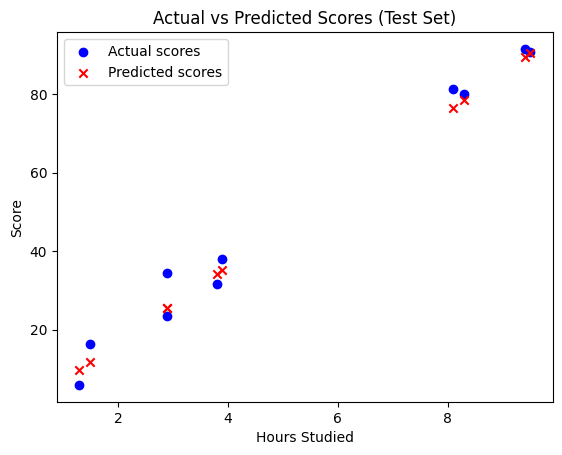

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color="blue", label="Actual scores")
plt.scatter(X_test, y_pred, color="red", marker="x", label="Predicted scores")
plt.title("Actual vs Predicted Scores (Test Set)")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.legend()
plt.show()